<h1>Lab4: Diffusion models</h1>

In [1]:
# Install dependencies
!pip install -q diffusers transformers accelerate safetensors datasets
!pip install -q bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.2 MB/s eta 0:00:00


Import all the python modules you need

In [2]:
import torch
from diffusers import StableDiffusionPipeline
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Import StableDiffusion model (might take some time...)

In [3]:
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16).to("cuda")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

**[TODO]** Try the StableDiffusion image generator with a text prompt of your choice. Generate an image from the desired prompt and visualize it. Try to customize the number of timesteps in the diffusion process by changing the num_inference_steps argument (default: 50). Hint: consult the documentation of the diffusers library (https://huggingface.co/docs/diffusers/quicktour).

  0%|          | 0/50 [00:00<?, ?it/s]

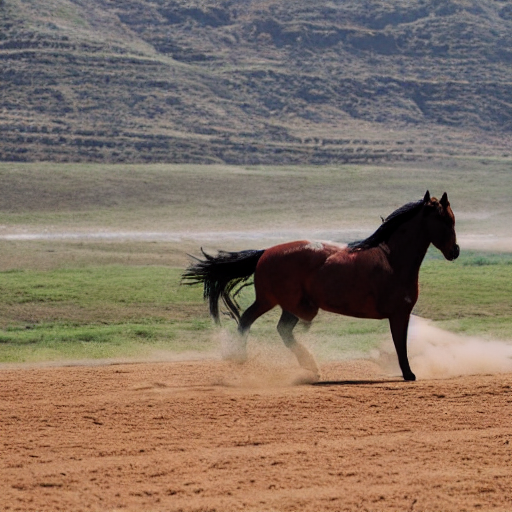

In [7]:
prompt = """
A horse that is running in the far west
"""
pipe(prompt, num_inference_steps = 50).images[0]

**[TODO]** Print out pipe.unet, pipe.text_encoder and describe their roles.

In [ ]:
print(pipe.unet)
print("\n\n\n\n\n")
print(pipe.text_encoder)

UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
              (attn1): Attention(
                (to_q): Linear(in_features=320, out_features=320, bias=False)
                (to_k): Linear(in_features=320, out_features=320, bias=False)
                (to_v): Linear(in_features=320, out_fe

The following function takes a batch of latent tensors (i.e. the "images" being produced at a certain timestep of the diffusion process) and applies the VAE decoder to convert them into RGB images (PIL library format)

In [4]:
def decode_latents_to_pil(pipe, latents):
    """
    latents: torch.Tensor (batch, channels, height, width)
    returns: list of PIL.Image
    """
    vae = pipe.vae
    # Move & cast to VAE device/dtype
    lat = latents.clone().detach()
    lat = lat.to(device=vae.device, dtype=vae.dtype)

    # Typical SD VAE scaling factor; try to read from config if present
    try:
        scale = pipe.vae.config.scaling_factor
    except Exception:
        scale = 0.18215

    lat = lat / scale

    with torch.no_grad():
        decoded = vae.decode(lat)

    # decoded can be a ModelOutput with .sample or a tensor directly
    if hasattr(decoded, "sample"):
        decoded = decoded.sample

    # decoded shape: (B, C, H, W) in [-1, 1] typically
    decoded = decoded.cpu()
    decoded = (decoded / 2 + 0.5).clamp(0, 1)  # to [0,1]
    arr = decoded.permute(0, 2, 3, 1).numpy()   # (B,H,W,C)

    pil_images = [Image.fromarray((im * 255).astype("uint8")) for im in arr]
    return pil_images

**[TODO]** The diffusers pipeline can be probed with callback functions like *callback_fn(step, timestep, latents)* where step is a counter (0,1,...,n_timesteps-1) indicating the current diffusion timestep being processed, timestep is the actual timestep value (depends on scheduler), and latents is the current latent representation being denoised of size (batch, 4, 64, 64) for StableDiffusion. The callback function can be passed to the pipeline to execute some code during the diffusion process. Write a callback that decodes the latents into an RGB image every 5 diffusion steps and saves all the images in a list (you will need the decode_latents_to_pil function from the previous cell). Then visualize the saved images. What do they represent?

In [5]:

def callback_fn(pipeline, step: int, timestep: int, callback_kwargs: dict):
    latents = callback_kwargs["latents"]
    if step % 5 == 0:
        # Ensure latents are on CPU and convert to float for decoding
        current_latents_cpu = latents.detach().cpu().float()
        images = decode_latents_to_pil(pipeline, current_latents_cpu)
        history.extend(images)
    return callback_kwargs

  0%|          | 0/50 [00:00<?, ?it/s]

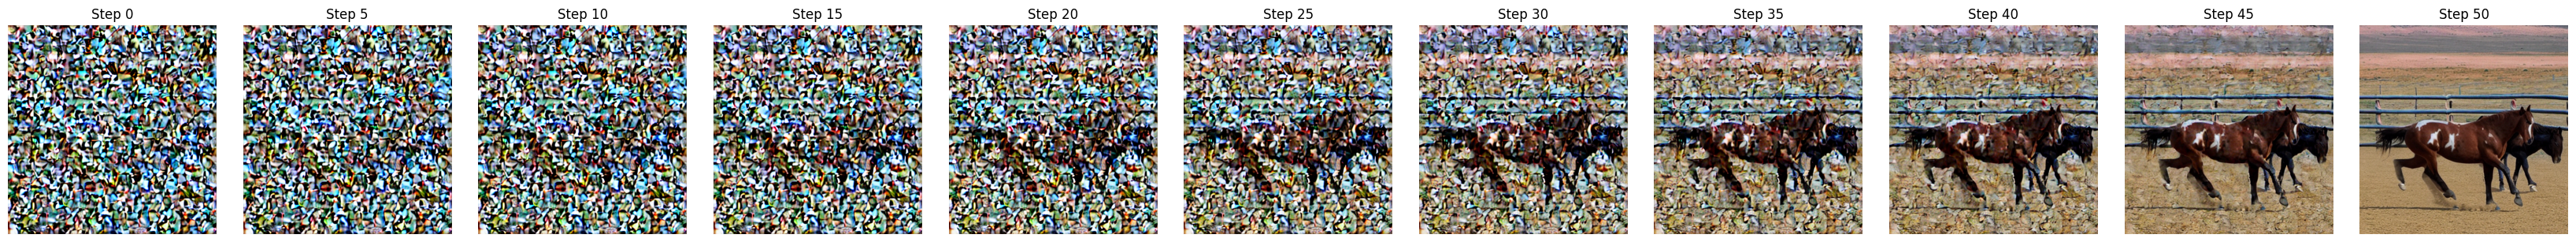

Final image:


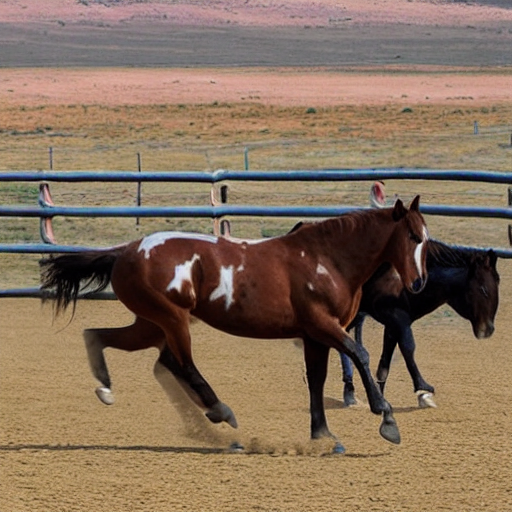

In [8]:
# Generate an image with the callback
history = []
final_image = pipe(prompt, callback_on_step_end=callback_fn, callback_on_step_end_tensor_inputs=["latents"], num_inference_steps=50).images[0]

num_images = len(history)
fig, axes = plt.subplots(1, num_images, figsize=(num_images * 3, 3))

# Handle the case of a single image gracefully (axes is not an array then)
if num_images == 1:
    axes = [axes]

for i, img in enumerate(history):
    axes[i].imshow(img)
    axes[i].set_title(f'Step {i*5}') # Assuming steps are saved every 5 steps
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("Final image:")
display(final_image)


**[TODO]** Change the value for the Classifier-Free Guidance parameter and discuss what happens for higher or lower values. Note: you can fix the noise realization by passing a seed such as torch.manual_seed(47) to the pipe "generator" argument.

Generating image with guidance_scale = 1.0


  0%|          | 0/50 [00:00<?, ?it/s]

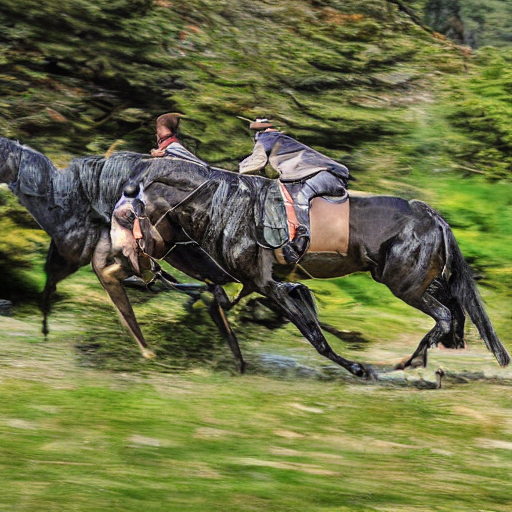

Generating image with guidance_scale = 7.5


  0%|          | 0/50 [00:00<?, ?it/s]

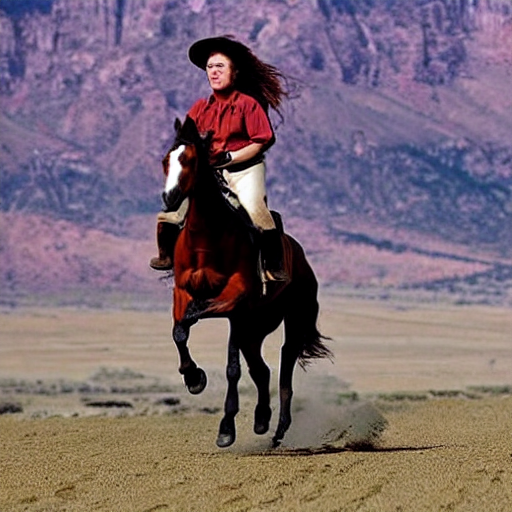

Generating image with guidance_scale = 20.0


  0%|          | 0/50 [00:00<?, ?it/s]

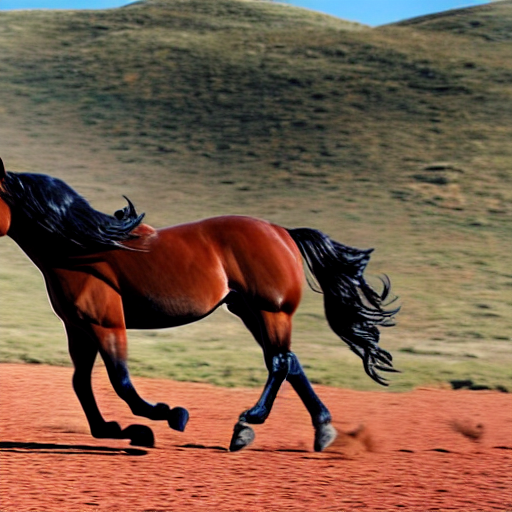

In [9]:
generator = torch.Generator("cuda").manual_seed(47) # Fixed seed for reproducibility

def generate_and_display_image(guidance_scale_value):
    print(f"Generating image with guidance_scale = {guidance_scale_value}")
    image = pipe(prompt, guidance_scale=guidance_scale_value, generator=generator, num_inference_steps=50).images[0]
    display(image)

# Generate images with different guidance_scale values
generate_and_display_image(1.0) # Lower value
generate_and_display_image(7.5) # Default/typical value
generate_and_display_image(20.0) # Higher value

**[TODO]** Image-to-image translation: transform a horse into a zebra. Use the AutoPipelineForImage2Image pipeline to transform the provided horse_painting.png into an image of a zebra. The pipeline has a *strength* parameter that lets you control how many diffusion steps are performed on a noisy version of the horse (strength close to 1 means close to all the original number of steps, i.e. horse almost disappears in noise and generation might create something very different).

In [1]:
from diffusers import AutoPipelineForImage2Image
from diffusers.utils import load_image
from PIL import Image
import gc
gc.collect()
torch.cuda.empty_cache()


image = Image.open("/content/horse_painting.png")

print("Original Image (Horse Painting):")
display(image)

# Load the image-to-image pipeline
# We'll reuse the model_id from the text-to-image pipeline
pipeline_img2img = AutoPipelineForImage2Image.from_pretrained(model_id, torch_dtype=torch.float16).to("cuda")

# Define the prompt for the target image
prompt_zebra = "a zebra, high quality, detailed, natural, photo realistic"

# Function to generate and display image with different strength
def generate_img2img(image, prompt, strength_value):
    print(f"\nGenerating image with strength = {strength_value}:")
    # Use the same generator for reproducibility if needed, but for img2img, strength is more impactful
    # generator = torch.Generator("cuda").manual_seed(47)
    output_image = pipeline_img2img(prompt=prompt, image=image, strength=strength_value, guidance_scale=7.5).images[0]
    display(output_image)

# Experiment with different strength values
# Strength close to 0: less change from original
generate_img2img(image, prompt_zebra, 0.3)

# Medium strength: noticeable transformation
generate_img2img(image, prompt_zebra, 0.7)

# High strength: almost a new image, original structure might be lost
generate_img2img(image, prompt_zebra, 0.95)

KeyboardInterrupt: 

In [ ]:
# in case of out of memory issues
#import gc
#del pipe
#del pipeline
#gc.collect()
#torch.cuda.empty_cache()